# GC Example 08: Inner vs Outer Halo Classification

**EPS Research — Milky Way GC Corpus v1.3.2**

Inner halo (R_GC < 8 kpc) vs outer halo (R_GC > 8 kpc) clusters
have different formation histories and chemical properties.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


Inner halo (R_GC < 8 kpc): 94
Outer halo (R_GC >= 8 kpc): 63
Inner median [Fe/H]: -1.04
Outer median [Fe/H]: -1.59


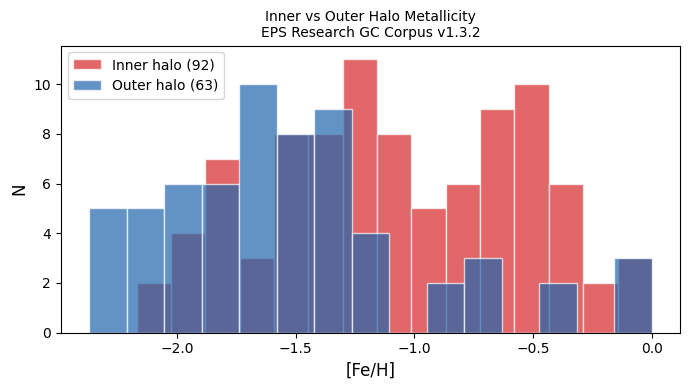

In [3]:
inner=[c for c in clusters if c.get('distances') and c['distances'].get('r_gc_kpc') and c['distances']['r_gc_kpc']<8]
outer=[c for c in clusters if c.get('distances') and c['distances'].get('r_gc_kpc') and c['distances']['r_gc_kpc']>=8]
print(f"Inner halo (R_GC < 8 kpc): {len(inner)}")
print(f"Outer halo (R_GC >= 8 kpc): {len(outer)}")
inner_feh=[c['metallicity']['feh'] for c in inner if c.get('metallicity') and c['metallicity'].get('feh') is not None]
outer_feh=[c['metallicity']['feh'] for c in outer if c.get('metallicity') and c['metallicity'].get('feh') is not None]
print(f"Inner median [Fe/H]: {np.median(inner_feh):.2f}")
print(f"Outer median [Fe/H]: {np.median(outer_feh):.2f}")
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(inner_feh,bins=15,alpha=0.7,color='#d62728',label=f'Inner halo ({len(inner_feh)})',edgecolor='white')
ax.hist(outer_feh,bins=15,alpha=0.7,color='#2166ac',label=f'Outer halo ({len(outer_feh)})',edgecolor='white')
ax.set_xlabel('[Fe/H]',fontsize=12); ax.set_ylabel('N',fontsize=12)
ax.set_title('Inner vs Outer Halo Metallicity\nEPS Research GC Corpus v1.3.2',fontsize=10)
ax.legend(); plt.tight_layout(); plt.savefig('gc08_inner_outer.png',dpi=150,bbox_inches='tight'); plt.show()